# LSTM: Como Funciona Por Dentro

**Pregunta:** Ya sabemos que Gradient Descent optimiza parametros iterativamente. Pero una LSTM tiene puertas, estados ocultos, memoria... como funciona todo eso internamente?

---

## 1. El Problema: Por que no basta con regresion?

En regresion lineal (y en Random Forest, XGBoost, etc.), cada observacion se trata como **independiente**. Pero en series temporales, el **orden importa**:

- El sensor_7 del motor en el ciclo 100 depende de lo que paso en los ciclos 95-99
- Una frase como "el gato se sento en el ___" depende de las palabras anteriores
- La temperatura de manana depende de la de hoy y ayer

Necesitamos un modelo que tenga **memoria** — que recuerde lo que vio antes.

## 2. Redes Neuronales: El Bloque Basico

Antes de LSTM, necesitamos entender una neurona artificial.

### Una neurona = regresion lineal + activacion

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_p x_p = \mathbf{w}^T \mathbf{x} + b$$

$$a = \sigma(z)$$

Donde:
- $\mathbf{w}$ son los pesos (equivalente a los betas)
- $b$ es el bias (equivalente a $\beta_0$)
- $\sigma$ es una funcion de activacion (sigmoid, tanh, ReLU)

**Es literalmente regresion lineal con una funcion no lineal encima.** Y los pesos se optimizan con... gradient descent.

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_55364/3770917667.py:21: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_title('Sigmoid: $\sigma(z) = 1/(1+e^{-z})$\nComprime a [0, 1]', fontsize=12, fontweight='bold')
/tmp/ipykernel_55364/3770917667.py:28: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_title('Tanh: $\sigma(z) = tanh(z)$\nComprime a [-1, 1]', fontsize=12, fontweight='bold')
/tmp/ipykernel_55364/3770917667.py:34: SyntaxWarning: invalid escape sequence '\s'
  axes[2].set_title('ReLU: $\sigma(z) = max(0, z)$\nSimple y efectiva', fontsize=12, fontweight='bold')


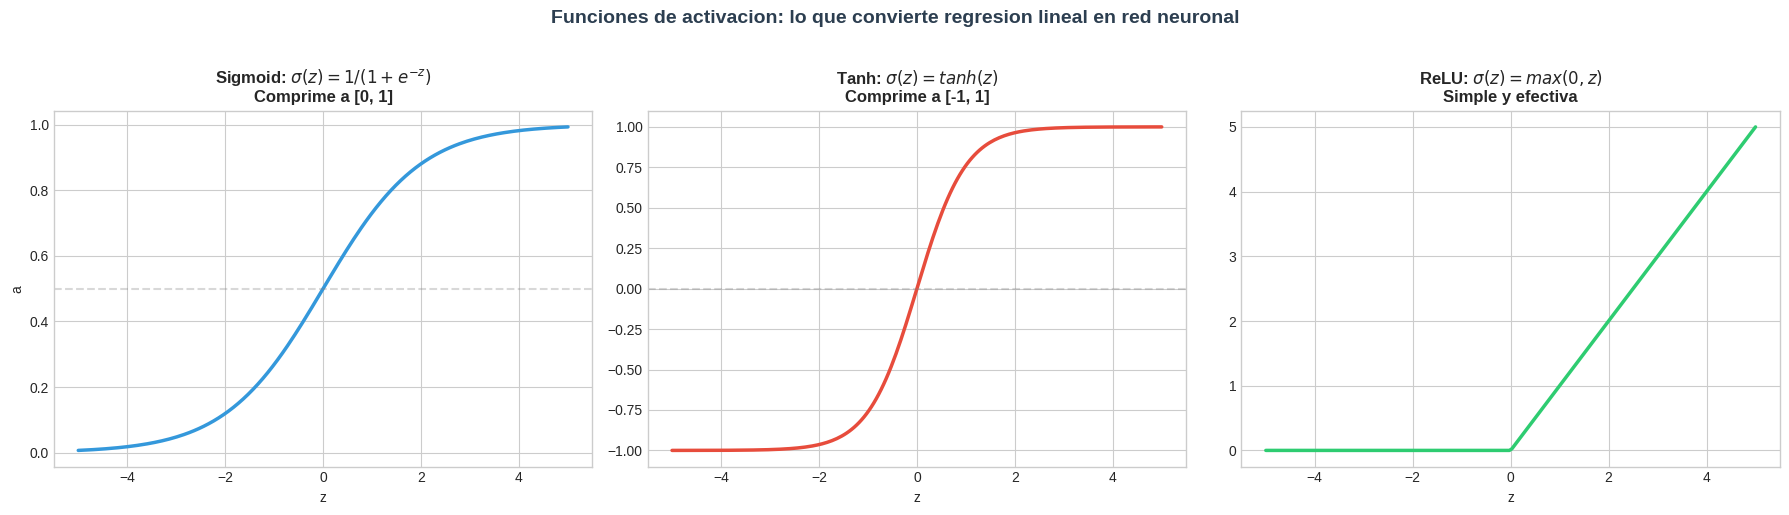

Sin activacion: una red de 100 capas lineales = una sola capa lineal (composicion de lineales = lineal)
Con activacion: cada capa puede aprender transformaciones no lineales progresivamente mas complejas


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
C_PRIMARY = '#3498db'
C_DANGER = '#e74c3c'
C_SUCCESS = '#2ecc71'
C_DARK = '#2c3e50'
C_ORANGE = '#f39c12'
C_PURPLE = '#9b59b6'

# === Una neurona: regresion + activacion ===
x = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sigmoid
axes[0].plot(x, 1/(1+np.exp(-x)), color=C_PRIMARY, linewidth=2.5)
axes[0].set_title('Sigmoid: $\sigma(z) = 1/(1+e^{-z})$\nComprime a [0, 1]', fontsize=12, fontweight='bold')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.3)
axes[0].set_xlabel('z')
axes[0].set_ylabel('a')

# Tanh
axes[1].plot(x, np.tanh(x), color=C_DANGER, linewidth=2.5)
axes[1].set_title('Tanh: $\sigma(z) = tanh(z)$\nComprime a [-1, 1]', fontsize=12, fontweight='bold')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.3)
axes[1].set_xlabel('z')

# ReLU
axes[2].plot(x, np.maximum(0, x), color=C_SUCCESS, linewidth=2.5)
axes[2].set_title('ReLU: $\sigma(z) = max(0, z)$\nSimple y efectiva', fontsize=12, fontweight='bold')
axes[2].set_xlabel('z')

plt.suptitle('Funciones de activacion: lo que convierte regresion lineal en red neuronal',
             fontsize=14, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

print("Sin activacion: una red de 100 capas lineales = una sola capa lineal (composicion de lineales = lineal)")
print("Con activacion: cada capa puede aprender transformaciones no lineales progresivamente mas complejas")

## 3. Red Neuronal Recurrente (RNN): La Idea del Loop

Una RNN procesa secuencias **un paso a la vez**, manteniendo un **estado oculto** $h_t$ que actua como "memoria":

```
Paso 1: x_1 → [RNN] → h_1
Paso 2: x_2 + h_1 → [RNN] → h_2
Paso 3: x_3 + h_2 → [RNN] → h_3
...
```

La formula de una RNN simple:

$$h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b_h)$$

- $x_t$: entrada en el paso $t$ (ej: lecturas de sensores del ciclo $t$)
- $h_{t-1}$: estado oculto del paso anterior (la "memoria")
- $W_{xh}$, $W_{hh}$: matrices de pesos (se aprenden con gradient descent)
- $h_t$: nuevo estado oculto

**El estado oculto es la memoria.** Cada paso combina la entrada actual con lo que recuerda del pasado.

### El problema: la RNN simple OLVIDA

Con secuencias largas, la informacion de los primeros pasos se diluye (gradientes que se multiplican muchas veces → se hacen 0 o explotan). Esto se llama **vanishing/exploding gradients**.

Para un motor con 200 ciclos, una RNN simple no puede recordar lo que paso en el ciclo 10 cuando llega al ciclo 200.

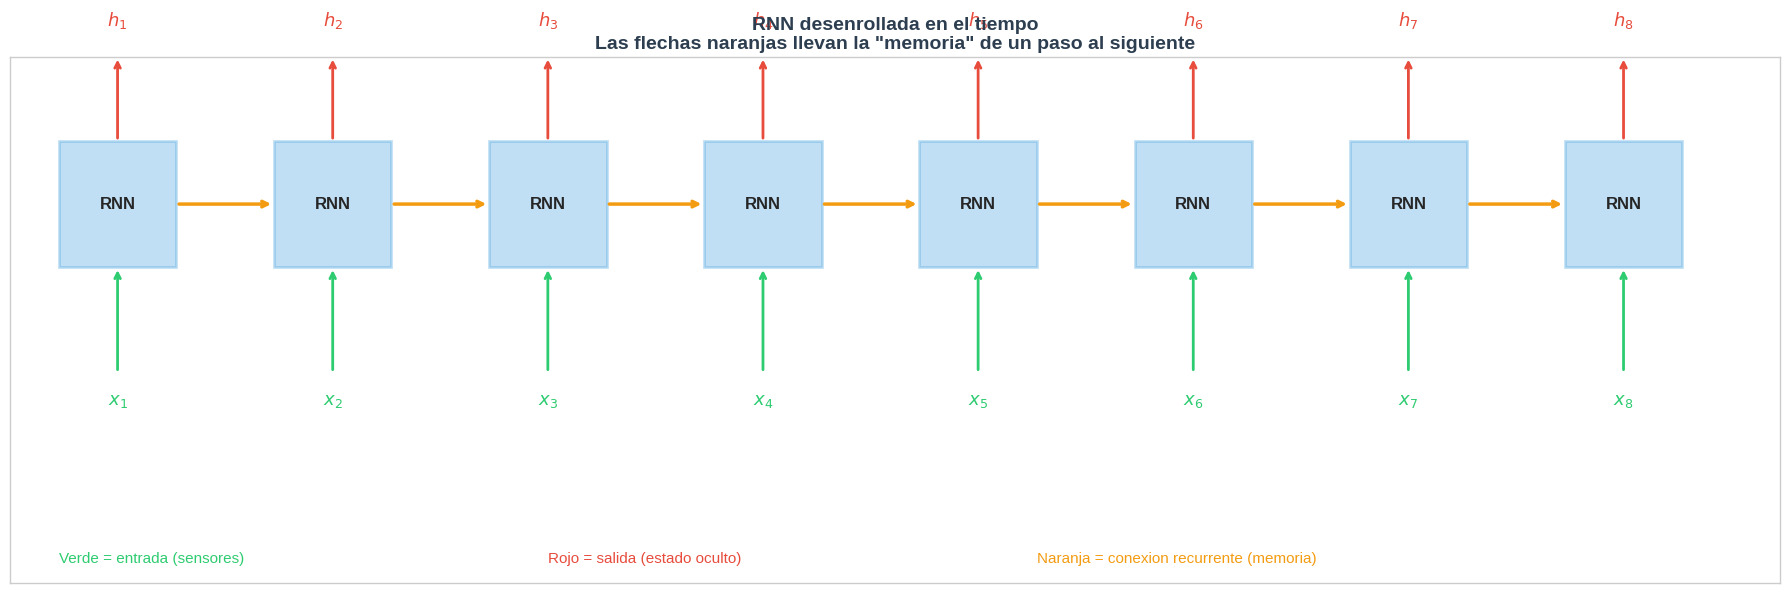

In [2]:
# === Visualizar: como una RNN simple procesa una secuencia ===
fig, ax = plt.subplots(figsize=(18, 6))

n_steps = 8
y_pos = 0.5

for t in range(n_steps):
    x_pos = t * 2.2
    
    # Caja RNN
    rect = plt.Rectangle((x_pos, y_pos - 0.3), 1.2, 0.6, 
                          facecolor=C_PRIMARY, alpha=0.3, edgecolor=C_PRIMARY, linewidth=2)
    ax.add_patch(rect)
    ax.text(x_pos + 0.6, y_pos, 'RNN', ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Entrada x_t (flecha desde abajo)
    ax.annotate('', xy=(x_pos + 0.6, y_pos - 0.3), xytext=(x_pos + 0.6, y_pos - 0.8),
                arrowprops=dict(arrowstyle='->', color=C_SUCCESS, lw=2))
    ax.text(x_pos + 0.6, y_pos - 0.95, f'$x_{{{t+1}}}$', ha='center', fontsize=13, color=C_SUCCESS)
    
    # Salida h_t (flecha hacia arriba)
    ax.annotate('', xy=(x_pos + 0.6, y_pos + 0.7), xytext=(x_pos + 0.6, y_pos + 0.3),
                arrowprops=dict(arrowstyle='->', color=C_DANGER, lw=2))
    ax.text(x_pos + 0.6, y_pos + 0.85, f'$h_{{{t+1}}}$', ha='center', fontsize=13, color=C_DANGER)
    
    # Flecha h_{t-1} → h_t (conexion recurrente)
    if t < n_steps - 1:
        ax.annotate('', xy=((t+1)*2.2, y_pos), xytext=(x_pos + 1.2, y_pos),
                    arrowprops=dict(arrowstyle='->', color=C_ORANGE, lw=2.5))

ax.set_xlim(-0.5, n_steps * 2.2)
ax.set_ylim(-1.3, 1.2)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('RNN desenrollada en el tiempo\nLas flechas naranjas llevan la "memoria" de un paso al siguiente',
             fontsize=14, fontweight='bold', color=C_DARK)

# Leyenda
ax.text(0, -1.2, 'Verde = entrada (sensores)', color=C_SUCCESS, fontsize=11)
ax.text(5, -1.2, 'Rojo = salida (estado oculto)', color=C_DANGER, fontsize=11)
ax.text(10, -1.2, 'Naranja = conexion recurrente (memoria)', color=C_ORANGE, fontsize=11)

plt.tight_layout()
plt.show()

## 4. LSTM: La Solucion al Olvido

**Long Short-Term Memory** (Hochreiter & Schmidhuber, 1997) resuelve el problema de la memoria a largo plazo con un diseno ingenioso: **tres puertas** que controlan el flujo de informacion.

La clave: ademas del estado oculto $h_t$, la LSTM tiene un **estado de celda** $C_t$ — una "autopista de memoria" que puede transportar informacion a traves de muchos pasos sin degradarse.

### Las 3 puertas

| Puerta | Nombre | Que hace | Analogia |
|--------|--------|----------|----------|
| $f_t$ | **Forget Gate** | Decide que OLVIDAR del estado anterior | "Borra de la pizarra lo que ya no sirve" |
| $i_t$ | **Input Gate** | Decide que informacion NUEVA guardar | "Escribe en la pizarra lo importante de hoy" |
| $o_t$ | **Output Gate** | Decide que parte de la memoria MOSTRAR | "Lee de la pizarra solo lo relevante ahora" |

### Las formulas (paso a paso)

**1. Forget Gate** — que olvidar?
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

Produce valores entre 0 y 1 para cada elemento del estado de celda. 0 = olvidar completamente, 1 = recordar todo.

**2. Input Gate** — que guardar?
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

$i_t$ decide cuanto guardar, $\tilde{C}_t$ son los valores candidatos a guardar.

**3. Actualizar estado de celda** — la memoria a largo plazo
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

Esto es la magia: $f_t \odot C_{t-1}$ olvida lo que no sirve, $i_t \odot \tilde{C}_t$ agrega lo nuevo.

**4. Output Gate** — que mostrar?
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

$h_t$ es lo que la LSTM "dice" — la salida que se usa para prediccion o se pasa al siguiente paso.

### Todos los pesos ($W_f, W_i, W_C, W_o, b_f, b_i, b_C, b_o$) se aprenden con GRADIENT DESCENT.
Es exactamente lo mismo que en regresion multiple, pero con muchos mas parametros.

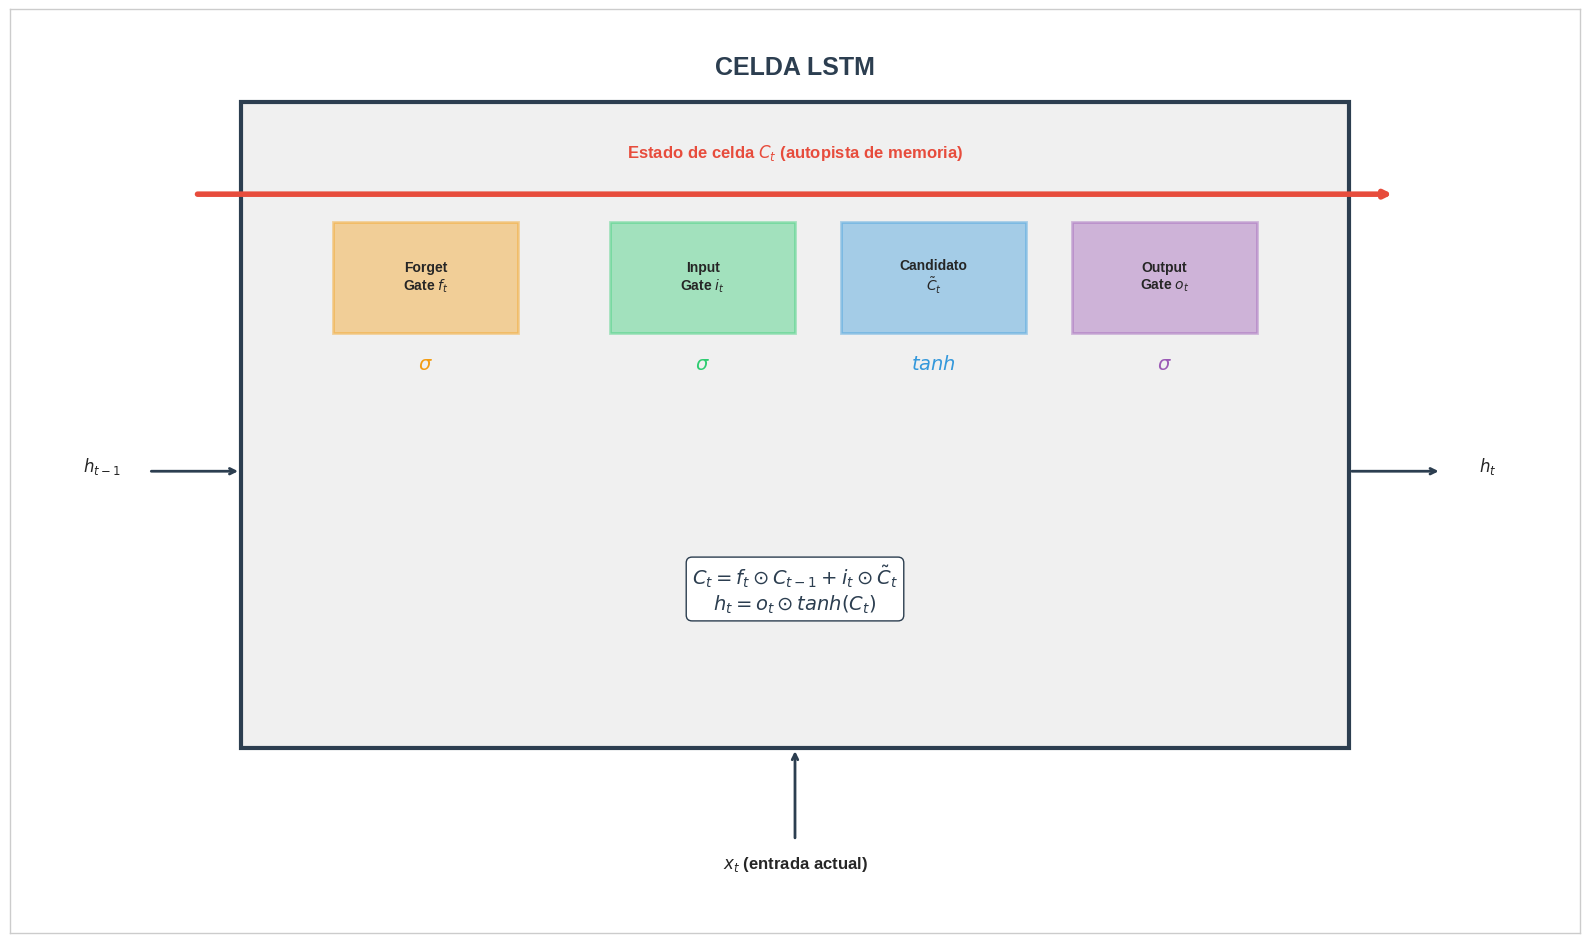

Cada puerta es basicamente: sigmoid(W @ [h_{t-1}, x_t] + b)
Es decir: regresion lineal + sigmoid. Los pesos W y b se aprenden con gradient descent.


In [3]:
# === Visualizar la arquitectura LSTM ===
fig, ax = plt.subplots(figsize=(16, 10))

# Caja principal
rect = plt.Rectangle((2, 1), 12, 7, facecolor='#f0f0f0', edgecolor=C_DARK, linewidth=3, zorder=0)
ax.add_patch(rect)
ax.text(8, 8.3, 'CELDA LSTM', ha='center', fontsize=18, fontweight='bold', color=C_DARK)

# Estado de celda (linea horizontal superior) - la autopista
ax.annotate('', xy=(14.5, 7), xytext=(1.5, 7),
            arrowprops=dict(arrowstyle='->', color=C_DANGER, lw=4))
ax.text(8, 7.4, 'Estado de celda $C_t$ (autopista de memoria)', ha='center', fontsize=12, 
        fontweight='bold', color=C_DANGER)

# Forget Gate
rect_f = plt.Rectangle((3, 5.5), 2, 1.2, facecolor=C_ORANGE, alpha=0.4, edgecolor=C_ORANGE, linewidth=2)
ax.add_patch(rect_f)
ax.text(4, 6.1, 'Forget\nGate $f_t$', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(4, 5.1, '$\sigma$', ha='center', fontsize=14, color=C_ORANGE)

# Input Gate
rect_i = plt.Rectangle((6, 5.5), 2, 1.2, facecolor=C_SUCCESS, alpha=0.4, edgecolor=C_SUCCESS, linewidth=2)
ax.add_patch(rect_i)
ax.text(7, 6.1, 'Input\nGate $i_t$', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(7, 5.1, '$\sigma$', ha='center', fontsize=14, color=C_SUCCESS)

# Candidate values
rect_c = plt.Rectangle((8.5, 5.5), 2, 1.2, facecolor=C_PRIMARY, alpha=0.4, edgecolor=C_PRIMARY, linewidth=2)
ax.add_patch(rect_c)
ax.text(9.5, 6.1, 'Candidato\n$\\tilde{C}_t$', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(9.5, 5.1, '$tanh$', ha='center', fontsize=14, color=C_PRIMARY)

# Output Gate
rect_o = plt.Rectangle((11, 5.5), 2, 1.2, facecolor=C_PURPLE, alpha=0.4, edgecolor=C_PURPLE, linewidth=2)
ax.add_patch(rect_o)
ax.text(12, 6.1, 'Output\nGate $o_t$', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(12, 5.1, '$\sigma$', ha='center', fontsize=14, color=C_PURPLE)

# Entradas
ax.annotate('', xy=(8, 1), xytext=(8, 0),
            arrowprops=dict(arrowstyle='->', color=C_DARK, lw=2))
ax.text(8, -0.3, '$x_t$ (entrada actual)', ha='center', fontsize=12, fontweight='bold')

ax.annotate('', xy=(2, 4), xytext=(1, 4),
            arrowprops=dict(arrowstyle='->', color=C_DARK, lw=2))
ax.text(0.5, 4, '$h_{t-1}$', ha='center', fontsize=12, fontweight='bold')

# Salidas
ax.annotate('', xy=(15, 4), xytext=(14, 4),
            arrowprops=dict(arrowstyle='->', color=C_DARK, lw=2))
ax.text(15.5, 4, '$h_t$', ha='center', fontsize=12, fontweight='bold')

# Formula resumen
ax.text(8, 2.5, '$C_t = f_t \odot C_{t-1} + i_t \odot \\tilde{C}_t$\n$h_t = o_t \odot tanh(C_t)$', 
        ha='center', fontsize=14, fontweight='bold', color=C_DARK,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor=C_DARK))

ax.set_xlim(-0.5, 16.5)
ax.set_ylim(-1, 9)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print("Cada puerta es basicamente: sigmoid(W @ [h_{t-1}, x_t] + b)")
print("Es decir: regresion lineal + sigmoid. Los pesos W y b se aprenden con gradient descent.")

## 4.1 De donde salen las formulas? Origen e intuicion de cada puerta

Las puertas de la LSTM no se inventaron al azar. Cada una resuelve un problema especifico que tenia la RNN simple.

### El problema de la RNN simple

La RNN simple tiene UNA sola formula:

$$h_t = \tanh(W \cdot [h_{t-1}, x_t] + b)$$

Esto **sobreescribe** la memoria completamente en cada paso. Es como tener una pizarra donde BORRAS TODO y escribes de nuevo en cada ciclo. No puedes decidir que conservar y que borrar.

### La solucion de Hochreiter y Schmidhuber (1997)

La idea fue: **separar la memoria en un canal dedicado** ($C_t$, el cell state) y controlar el acceso con puertas que aprenden CUANDO abrir y cerrar.

---

### Forget Gate: $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$

**Problema que resuelve:** "Tengo informacion guardada. Cual sigo necesitando?"

**Por que sigmoid?** Porque sigmoid produce valores entre 0 y 1, que funcionan como **porcentajes de retencion**. Si $f_t = 0.9$, retiene el 90% de la memoria anterior. Si $f_t = 0.1$, borra el 90%.

**Por que $[h_{t-1}, x_t]$ como entrada?** Porque la decision de que olvidar depende TANTO de lo que recuerdas ($h_{t-1}$) como de lo que ves ahora ($x_t$). Ejemplo: si el sensor de temperatura sube bruscamente ($x_t$), quizas lo que sabias sobre "el motor esta estable" ($h_{t-1}$) ya no aplica.

**Los pesos $W_f$ se aprenden con gradient descent.** El modelo descubre por si solo CUANDO olvidar.

---

### Input Gate: $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$ y $\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$

**Problema que resuelve:** "De lo nuevo que estoy viendo, que vale la pena guardar?"

Son dos partes:
- **$\tilde{C}_t$ (candidato):** usa tanh para producir valores entre -1 y 1. Son los **contenidos** potenciales a guardar. Tanh y no sigmoid porque queremos que la memoria pueda tener valores negativos (representar "disminucion", "descenso", etc.)
- **$i_t$ (puerta):** usa sigmoid para decidir **cuanto** de cada candidato guardar (0% a 100%)

**Analogia:** $\tilde{C}_t$ es lo que escribirias en la pizarra. $i_t$ decide cuales de esas notas realmente valen la pena escribir.

---

### Actualizacion del Cell State: $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$

**Esta es la formula mas importante.** Es una suma ponderada:

- $f_t \odot C_{t-1}$: lo que CONSERVAS de la memoria anterior (ponderado por forget gate)
- $i_t \odot \tilde{C}_t$: lo NUEVO que agregas (ponderado por input gate)

**Por que una SUMA y no una multiplicacion?** Este es el truco genial. En la RNN simple, la informacion pasa por multiplicaciones repetidas ($h_t = \tanh(W \cdot h_{t-1} + ...)$), lo que causa vanishing gradients. Aqui es una **suma**. El gradiente de una suma es 1, asi que la informacion fluye por $C_t$ sin degradarse — como una **autopista**.

---

### Output Gate: $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$ y $h_t = o_t \odot \tanh(C_t)$

**Problema que resuelve:** "Tengo mucha informacion guardada, pero no toda es relevante AHORA."

- $\tanh(C_t)$: normaliza la memoria a [-1, 1]
- $o_t$: decide que porcentaje de la memoria mostrar como salida

**Ejemplo:** El cell state puede recordar que el motor tuvo un pico de temperatura hace 50 ciclos Y que la presion ha bajado gradualmente. Pero para predecir el RUL actual, quizas solo importa la presion. La output gate filtra.

---

### Resumen: por que esas funciones especificas

| Funcion | Donde se usa | Rango | Por que |
|---|---|---|---|
| **Sigmoid** ($\sigma$) | Todas las puertas | [0, 1] | Funciona como porcentaje/interruptor (0=cerrado, 1=abierto) |
| **Tanh** | Candidato $\tilde{C}_t$ y salida | [-1, 1] | Permite valores negativos, centrado en 0 |
| **Multiplicacion** ($\odot$) | Aplicar puertas | - | Escala cada elemento independientemente |
| **Suma** (+) | Actualizar $C_t$ | - | Preserva gradientes (evita vanishing gradient) |

## 4.2 Calculos Matriciales Detallados + Weight Sharing

**Pregunta clave:** Los pesos se recalculan en cada paso temporal? No, y esto es fundamental.

### Weight Sharing: Los pesos son FIJOS durante toda la secuencia

```
Paso 1: f_1 = sigmoid(Wf · [h_0, x_1] + bf)    ← mismos Wf, bf
Paso 2: f_2 = sigmoid(Wf · [h_1, x_2] + bf)    ← mismos Wf, bf
Paso 3: f_3 = sigmoid(Wf · [h_2, x_3] + bf)    ← mismos Wf, bf
```

**Lo que cambia en cada paso:** las entradas ($x_t$ y $h_{t-1}$), NO los pesos.

**Los pesos solo se actualizan DESPUES de procesar toda la secuencia**, con gradient descent.

### Dimensiones de las matrices

Para una LSTM con:
- `input_size = 3` (3 sensores)
- `hidden_size = 2` (estado oculto de dimension 2)

El vector concatenado $[h_{t-1}, x_t]$ tiene dimension `hidden_size + input_size = 5`

Cada puerta tiene:
- $W$: matriz de `hidden_size x (hidden_size + input_size)` = **2 x 5**
- $b$: vector de `hidden_size` = **2**

Veamos los calculos exactos con numeros.

In [ ]:
# === Calculos matriciales DETALLADOS de una LSTM ===
import numpy as np

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

# Dimensiones
input_size = 3    # 3 sensores (temperatura, presion, vibracion)
hidden_size = 2   # Estado oculto de dimension 2

print("=" * 70)
print("  LSTM: DIMENSIONES Y PESOS")
print("=" * 70)
print(f"  input_size  = {input_size} (sensores)")
print(f"  hidden_size = {hidden_size} (neuronas ocultas)")
print(f"  concatenado = {hidden_size + input_size} (h + x)")
print()

# Inicializar pesos (estos se FIJAN durante toda la secuencia)
# En la practica, gradient descent los ajusta ENTRE secuencias
Wf = np.random.randn(hidden_size, hidden_size + input_size) * 0.3
bf = np.zeros(hidden_size)
Wi = np.random.randn(hidden_size, hidden_size + input_size) * 0.3
bi = np.zeros(hidden_size)
Wc = np.random.randn(hidden_size, hidden_size + input_size) * 0.3
bc = np.zeros(hidden_size)
Wo = np.random.randn(hidden_size, hidden_size + input_size) * 0.3
bo = np.zeros(hidden_size)

print("PESOS (fijos durante toda la secuencia):")
print(f"  Wf (forget gate):  {Wf.shape} = {hidden_size}x{hidden_size+input_size}")
print(f"  Wi (input gate):   {Wi.shape}")
print(f"  Wc (candidato):    {Wc.shape}")
print(f"  Wo (output gate):  {Wo.shape}")
print(f"  Cada bias:         {bf.shape}")
print(f"\n  Total parametros: 4 x ({hidden_size}x{hidden_size+input_size} + {hidden_size}) = {4*(hidden_size*(hidden_size+input_size)+hidden_size)}")

print("\n  Wf =")
print(f"  {Wf}")
print(f"  bf = {bf}")

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
# === PASO 1: Procesar el primer ciclo del motor ===
# Secuencia: 3 lecturas de sensores por ciclo
# [temperatura, presion, vibracion]
sequence = [
    np.array([0.1, 0.5, 0.2]),   # Ciclo 1: motor sano
    np.array([0.3, 0.4, 0.4]),   # Ciclo 2: ligero desgaste
    np.array([0.8, 0.2, 0.9]),   # Ciclo 3: degradacion fuerte
]
cycle_labels = ['Sano', 'Desgaste leve', 'Degradacion']

# Estado inicial (ceros)
h = np.zeros(hidden_size)  # h_0 = [0, 0]
C = np.zeros(hidden_size)  # C_0 = [0, 0]

for t, (x_t, label) in enumerate(zip(sequence, cycle_labels)):
    print(f"\n{'='*70}")
    print(f"  PASO t={t+1}: {label}")
    print(f"  x_t = {x_t}  (temperatura={x_t[0]}, presion={x_t[1]}, vibracion={x_t[2]})")
    print(f"  h_{{t-1}} = {h}")
    print(f"{'='*70}")
    
    # Concatenar [h_{t-1}, x_t]
    combined = np.concatenate([h, x_t])
    print(f"\n  1. Concatenar [h_{{t-1}}, x_t] = {combined}  (dim={len(combined)})")
    
    # FORGET GATE
    z_f = Wf @ combined + bf
    f_t = sigmoid(z_f)
    print(f"\n  2. FORGET GATE:")
    print(f"     z_f = Wf @ combined + bf")
    print(f"     z_f = {Wf} @ {combined} + {bf}")
    print(f"     z_f = {z_f}")
    print(f"     f_t = sigmoid(z_f) = {f_t}")
    print(f"     Interpretacion: retener {f_t[0]*100:.0f}% y {f_t[1]*100:.0f}% de la memoria anterior")
    
    # INPUT GATE
    z_i = Wi @ combined + bi
    i_t = sigmoid(z_i)
    z_c = Wc @ combined + bc
    C_candidate = np.tanh(z_c)
    print(f"\n  3. INPUT GATE:")
    print(f"     i_t = sigmoid(Wi @ combined + bi) = {i_t}")
    print(f"     C_candidato = tanh(Wc @ combined + bc) = {C_candidate}")
    print(f"     Interpretacion: guardar {i_t[0]*100:.0f}% y {i_t[1]*100:.0f}% de lo nuevo")
    
    # ACTUALIZAR CELL STATE
    C_old = C.copy()
    C = f_t * C_old + i_t * C_candidate
    print(f"\n  4. ACTUALIZAR CELL STATE:")
    print(f"     C_t = f_t * C_{{t-1}} + i_t * C_candidato")
    print(f"     C_t = {f_t} * {C_old} + {i_t} * {C_candidate}")
    print(f"     C_t = {f_t * C_old} + {i_t * C_candidate}")
    print(f"     C_t = {C}")
    
    # OUTPUT GATE
    z_o = Wo @ combined + bo
    o_t = sigmoid(z_o)
    h = o_t * np.tanh(C)
    print(f"\n  5. OUTPUT GATE:")
    print(f"     o_t = sigmoid(Wo @ combined + bo) = {o_t}")
    print(f"     h_t = o_t * tanh(C_t) = {o_t} * {np.tanh(C)} = {h}")
    print(f"     Interpretacion: mostrar {o_t[0]*100:.0f}% y {o_t[1]*100:.0f}% de la memoria")

print(f"\n{'='*70}")
print(f"  RESULTADO FINAL despues de 3 pasos:")
print(f"  Cell State C_3 = {C}  (memoria acumulada)")
print(f"  Hidden State h_3 = {h}  (salida para prediccion)")
print(f"{'='*70}")
print(f"\n  NOTA: Los pesos Wf, Wi, Wc, Wo NO cambiaron en ningun paso.")
print(f"  Son los MISMOS en t=1, t=2 y t=3. Esto es weight sharing.")

### Cuando se actualizan los pesos?

El ciclo completo de entrenamiento es:

```
1. FORWARD (pesos FIJOS):
   Procesar 30 ciclos con los mismos Wf, Wi, Wc, Wo
   → Obtener prediccion (ej: RUL = 45)

2. LOSS:
   Comparar con realidad (ej: RUL real = 20)
   → MSE = (45-20)^2 = 625

3. BACKWARD (Backpropagation Through Time):
   Retroceder por los 30 pasos calculando:
   "Si Wf[0,0] hubiera sido 0.01 mayor, el error habria sido _"
   → Gradiente de cada peso

4. UPDATE (gradient descent):
   Wf := Wf - alpha * gradiente_Wf
   Wi := Wi - alpha * gradiente_Wi
   ... (una sola actualizacion para toda la secuencia)

5. REPETIR con la siguiente secuencia
```

**Los pesos se actualizan UNA VEZ por secuencia (o por batch), no en cada paso temporal.**

## 5. LSTM Paso a Paso: Ejemplo Numerico

Vamos a simular UNA celda LSTM con numeros reales para ver exactamente que pasa en cada puerta.

Escenario: un motor con 1 sensor. Valores altos = degradacion.

In [4]:
# === LSTM paso a paso con numeros reales ===
np.random.seed(42)

# Simular: pesos pequenos aleatorios (en realidad se aprenden con GD)
input_size = 1   # 1 sensor
hidden_size = 2  # estado oculto de dimension 2

# Pesos (normalmente los aprende gradient descent)
Wf = np.random.randn(hidden_size, hidden_size + input_size) * 0.5
bf = np.zeros(hidden_size)
Wi = np.random.randn(hidden_size, hidden_size + input_size) * 0.5
bi = np.zeros(hidden_size)
Wc = np.random.randn(hidden_size, hidden_size + input_size) * 0.5
bc = np.zeros(hidden_size)
Wo = np.random.randn(hidden_size, hidden_size + input_size) * 0.5
bo = np.zeros(hidden_size)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Secuencia de entrada: sensor de un motor (degradacion progresiva)
sensor_readings = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0]
labels = ['Sano', 'Sano', 'Sano', 'Desgaste', 'Degradado', 'Critico', 'Fallo']

# Estado inicial
h = np.zeros(hidden_size)
C = np.zeros(hidden_size)

print(f"{'Paso':>4} {'Sensor':>7} {'Estado':>10} {'Forget Gate':>15} {'Input Gate':>15} {'Cell State':>20} {'Hidden':>20}")
print("=" * 100)

h_history = []
C_history = []

for t, (x_val, label) in enumerate(zip(sensor_readings, labels)):
    x = np.array([x_val])
    
    # Concatenar h_{t-1} y x_t
    combined = np.concatenate([h, x])
    
    # 1. Forget gate
    f = sigmoid(Wf @ combined + bf)
    
    # 2. Input gate
    i = sigmoid(Wi @ combined + bi)
    C_candidate = np.tanh(Wc @ combined + bc)
    
    # 3. Actualizar cell state
    C = f * C + i * C_candidate
    
    # 4. Output gate
    o = sigmoid(Wo @ combined + bo)
    h = o * np.tanh(C)
    
    h_history.append(h.copy())
    C_history.append(C.copy())
    
    print(f"{t:>4} {x_val:>7.1f} {label:>10} f={f.round(3)} i={i.round(3)} C={C.round(3)} h={h.round(3)}")

print("\nObserva como el Cell State (C) ACUMULA informacion a lo largo del tiempo.")
print("El Hidden State (h) es lo que la LSTM 'muestra' en cada paso.")

Paso  Sensor     Estado     Forget Gate      Input Gate           Cell State               Hidden
   0     0.1       Sano f=[0.508 0.497] i=[0.494 0.494] C=[-0.043  0.008] h=[-0.022  0.004]
   1     0.2       Sano f=[0.515 0.49 ] i=[0.484 0.487] C=[-0.108  0.021] h=[-0.058  0.01 ]
   2     0.3       Sano f=[0.521 0.48 ] i=[0.472 0.478] C=[-0.183  0.038] h=[-0.101  0.017]
   3     0.5   Desgaste f=[0.534 0.466] i=[0.452 0.463] C=[-0.292  0.063] h=[-0.17   0.026]
   4     0.7  Degradado f=[0.546 0.447] i=[0.428 0.446] C=[-0.404  0.092] h=[-0.245  0.035]
   5     0.9    Critico f=[0.557 0.427] i=[0.403 0.429] C=[-0.502  0.121] h=[-0.314  0.042]
   6     1.0      Fallo f=[0.56  0.411] i=[0.385 0.419] C=[-0.565  0.142] h=[-0.358  0.048]

Observa como el Cell State (C) ACUMULA informacion a lo largo del tiempo.
El Hidden State (h) es lo que la LSTM 'muestra' en cada paso.


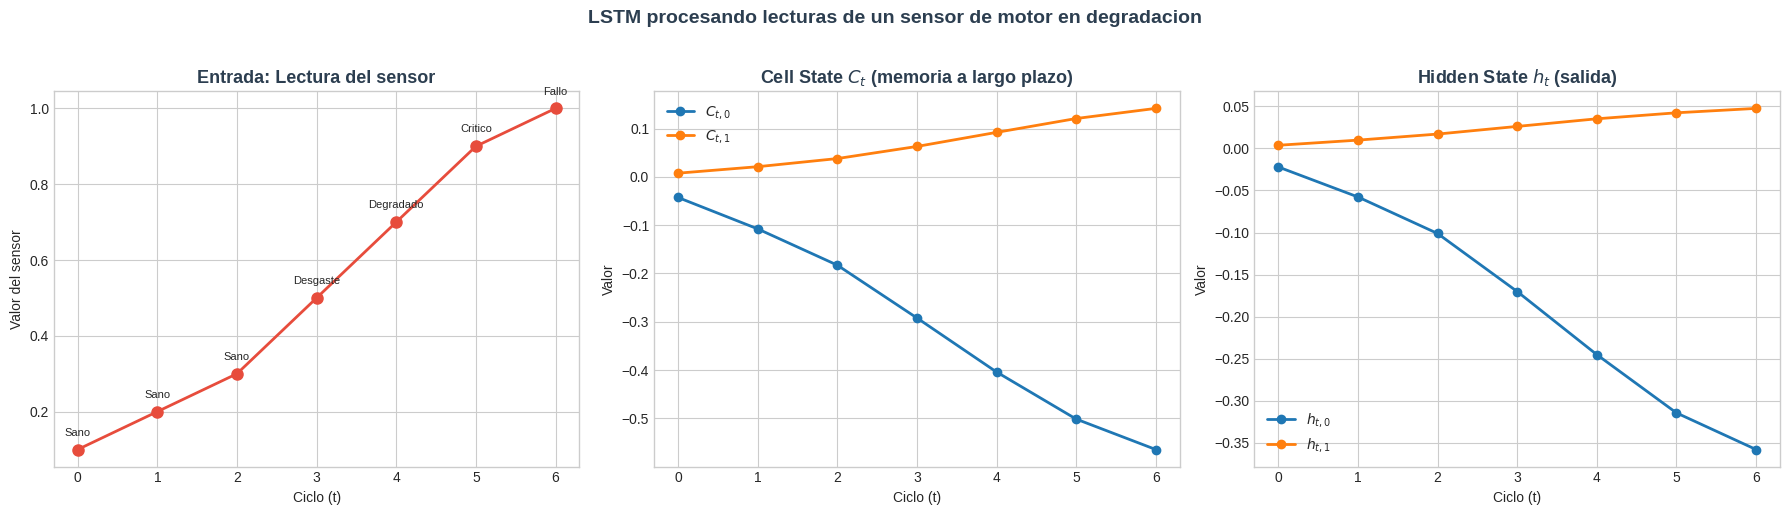

In [5]:
# === Visualizar la evolucion del estado ===
h_arr = np.array(h_history)
C_arr = np.array(C_history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Entrada (sensor)
ax = axes[0]
ax.plot(range(len(sensor_readings)), sensor_readings, 'o-', color=C_DANGER, linewidth=2, markersize=8)
for t, (val, label) in enumerate(zip(sensor_readings, labels)):
    ax.annotate(label, (t, val), textcoords="offset points", xytext=(0, 10), fontsize=8, ha='center')
ax.set_title('Entrada: Lectura del sensor', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('Ciclo (t)')
ax.set_ylabel('Valor del sensor')

# Cell State
ax = axes[1]
for dim in range(hidden_size):
    ax.plot(range(len(C_arr)), C_arr[:, dim], 'o-', linewidth=2, markersize=6, label=f'$C_{{t,{dim}}}$')
ax.set_title('Cell State $C_t$ (memoria a largo plazo)', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('Ciclo (t)')
ax.set_ylabel('Valor')
ax.legend()

# Hidden State
ax = axes[2]
for dim in range(hidden_size):
    ax.plot(range(len(h_arr)), h_arr[:, dim], 'o-', linewidth=2, markersize=6, label=f'$h_{{t,{dim}}}$')
ax.set_title('Hidden State $h_t$ (salida)', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('Ciclo (t)')
ax.set_ylabel('Valor')
ax.legend()

plt.suptitle('LSTM procesando lecturas de un sensor de motor en degradacion',
             fontsize=14, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

## 6. Como se Entrena una LSTM?

Exactamente igual que regresion multiple, pero con mas parametros:

1. **Forward pass:** Procesar toda la secuencia, paso a paso, calculando $h_t$ y $C_t$ en cada paso
2. **Calcular loss:** Comparar la prediccion final con el valor real (ej: MSE entre RUL predicho y real)
3. **Backward pass (Backpropagation Through Time):** Calcular gradientes de TODOS los pesos retrocediendo en el tiempo
4. **Actualizar pesos:** $W := W - \alpha \cdot \nabla W$ (gradient descent)

### Backpropagation Through Time (BPTT)

Es gradient descent desenrollado en el tiempo. Si la secuencia tiene 30 pasos, es como tener 30 "capas" y calcular gradientes a traves de todas ellas.

**Por que LSTM resuelve el vanishing gradient:** El estado de celda $C_t$ se actualiza con **sumas** ($C_t = f_t \odot C_{t-1} + \ldots$), no con multiplicaciones repetidas. Las sumas preservan el gradiente mucho mejor que las multiplicaciones.

### Cantidad de parametros

Para una LSTM con `input_size` features y `hidden_size` neuronas:
- 4 matrices de pesos: $W_f, W_i, W_C, W_o$ (una por puerta + candidato)
- Cada una de tamano: `hidden_size x (hidden_size + input_size)`
- 4 vectores de bias
- **Total:** $4 \times hidden\_size \times (hidden\_size + input\_size) + 4 \times hidden\_size$

In [6]:
# === Contar parametros de LSTM ===
configs = [
    ("LSTM(32), 14 sensores", 14, 32),
    ("LSTM(64), 14 sensores", 14, 64),
    ("LSTM(64) + LSTM(32)", 14, 64),  # Solo primera capa
    ("LSTM(128), 50 features", 50, 128),
]

print(f"{'Configuracion':<30} {'Input':>6} {'Hidden':>7} {'Parametros':>12}")
print("=" * 60)

for name, inp, hid in configs:
    # 4 puertas x (hidden x (hidden + input) + hidden bias)
    params = 4 * (hid * (hid + inp) + hid)
    print(f"{name:<30} {inp:>6} {hid:>7} {params:>12,}")

print(f"\n{'Comparacion con regresion lineal':<30} {14:>6} {'1':>7} {15:>12}")
print("\nUna LSTM con 64 neuronas y 14 features tiene ~20,000 parametros.")
print("Todos se optimizan con gradient descent.")
print("Por eso deep learning necesita mas datos y mas computo que regresion.")

Configuracion                   Input  Hidden   Parametros
LSTM(32), 14 sensores              14      32        6,016
LSTM(64), 14 sensores              14      64       20,224
LSTM(64) + LSTM(32)                14      64       20,224
LSTM(128), 50 features             50     128       91,648

Comparacion con regresion lineal     14       1           15

Una LSTM con 64 neuronas y 14 features tiene ~20,000 parametros.
Todos se optimizan con gradient descent.
Por eso deep learning necesita mas datos y mas computo que regresion.


## 7. De la Teoria al Proyecto: LSTM para RUL

En nuestro proyecto de mantenimiento predictivo:

### Entrada
- Secuencia de 30 ciclos (ventana temporal)
- 14 sensores utiles por ciclo + features derivadas
- Shape: `(batch_size, 30, n_features)`

### Arquitectura
```
Secuencia de 30 ciclos
         |
    [LSTM(64)]  ← Procesa los 30 pasos, genera h_1, h_2, ..., h_30
         |        (return_sequences=True → pasa todos los h_t)
   [Dropout(0.2)] ← Regularizacion (apaga neuronas al azar)
         |
    [LSTM(32)]  ← Segunda capa, procesa la secuencia de h_t
         |        (return_sequences=False → solo devuelve h_30)
   [Dropout(0.2)]
         |
    [Dense(1)]  ← Una neurona: RUL predicho
```

### Loss y Optimizador
- **Loss:** MSE (Mean Squared Error) — exactamente igual que en regresion
- **Optimizador:** Adam (variante sofisticada de gradient descent con learning rate adaptativo)

In [7]:
# === Ejemplo real: LSTM en Keras ===
import tensorflow as tf
from tensorflow import keras
from keras import layers

# Arquitectura del proyecto
model = keras.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(30, 14)),
    layers.Dropout(0.2),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)  # RUL predicho
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

print("\nCada 'param' es un peso que se optimiza con gradient descent.")
print("Adam = gradient descent + momentum + learning rate adaptativo por parametro.")

I0000 00:00:1774057281.011053   55364 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774057281.049797   55364 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774057281.955029   55364 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1774057282.832054   55364 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries men

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,185 (129.63 KB)

 Trainable params: 33,185 (129.63 KB)

 Non-trainable params: 0 (0.00 B)


Cada 'param' es un peso que se optimiza con gradient descent.
Adam = gradient descent + momentum + learning rate adaptativo por parametro.


X shape: (50, 30, 5) (motores, pasos, features)
y shape: (50,) (RUL de cada motor)


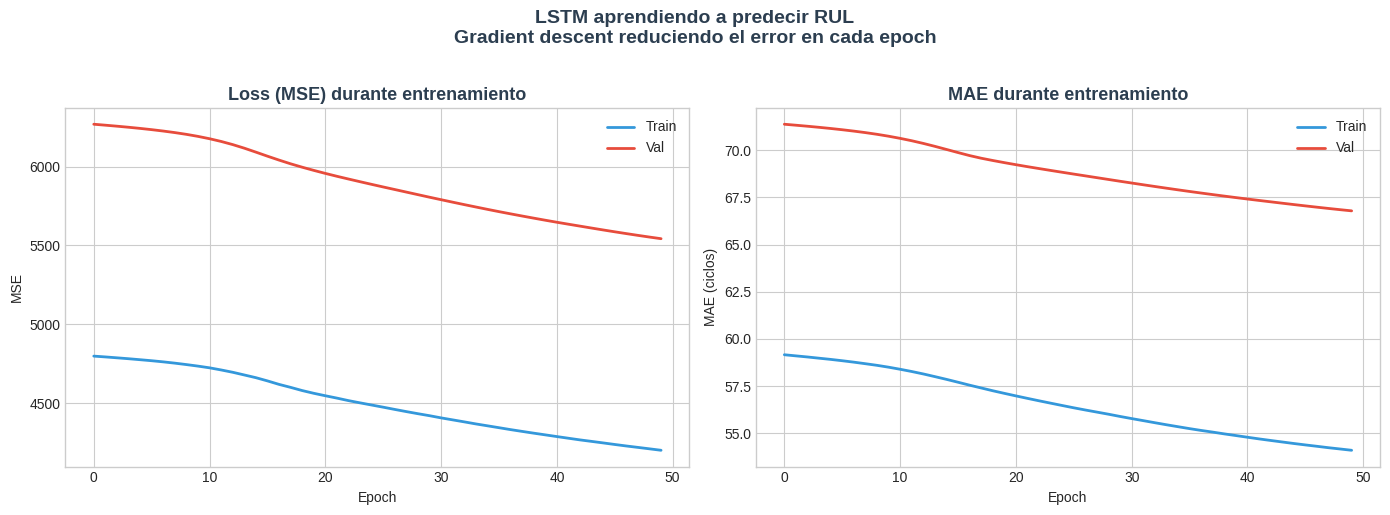

MSE final train: 4201.8
MSE final val: 5542.8


In [8]:
# === Simular entrenamiento con datos sinteticos ===
np.random.seed(42)

# Crear secuencias sinteticas (simular degradacion de motor)
n_motors = 50
seq_length = 30
n_features = 5

X_sim = []
y_sim = []

for _ in range(n_motors):
    rul = np.random.randint(0, 130)
    # Secuencia: valores que aumentan con la degradacion
    base = np.random.randn(seq_length, n_features) * 0.3
    trend = np.linspace(0, (130 - rul) / 130, seq_length).reshape(-1, 1)
    seq = base + trend
    X_sim.append(seq)
    y_sim.append(rul)

X_sim = np.array(X_sim)
y_sim = np.array(y_sim, dtype=float)

print(f"X shape: {X_sim.shape} (motores, pasos, features)")
print(f"y shape: {y_sim.shape} (RUL de cada motor)")

# Modelo pequeno para demo
model_demo = keras.Sequential([
    layers.LSTM(16, return_sequences=False, input_shape=(seq_length, n_features)),
    layers.Dense(1)
])
model_demo.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenar
history = model_demo.fit(X_sim, y_sim, epochs=50, batch_size=16, 
                         validation_split=0.2, verbose=0)

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train', color=C_PRIMARY, linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val', color=C_DANGER, linewidth=2)
axes[0].set_title('Loss (MSE) durante entrenamiento', fontsize=13, fontweight='bold', color=C_DARK)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train', color=C_PRIMARY, linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val', color=C_DANGER, linewidth=2)
axes[1].set_title('MAE durante entrenamiento', fontsize=13, fontweight='bold', color=C_DARK)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (ciclos)')
axes[1].legend()

plt.suptitle('LSTM aprendiendo a predecir RUL\nGradient descent reduciendo el error en cada epoch',
             fontsize=14, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

print(f"MSE final train: {history.history['loss'][-1]:.1f}")
print(f"MSE final val: {history.history['val_loss'][-1]:.1f}")

## 8. Resumen: De Regresion a LSTM

| Concepto | Regresion Lineal | LSTM |
|---|---|---|
| **Modelo** | $y = W^T x + b$ | Puertas con $\sigma(W \cdot [h, x] + b)$ |
| **Parametros** | p+1 betas | Miles (4 puertas x matrices) |
| **Optimizacion** | Ecuacion Normal o GD | Solo Gradient Descent (Adam) |
| **Memoria** | Ninguna (cada obs. independiente) | $C_t$ (largo plazo) + $h_t$ (corto plazo) |
| **Entrada** | 1 vector por muestra | Secuencia de vectores |
| **Ventaja** | Simple, interpretable | Captura patrones temporales |

### La conexion fundamental

Una LSTM es, en su nucleo, **muchas regresiones lineales + activaciones no lineales** organizadas en una estructura con memoria. Cada puerta es:

$$\text{puerta} = \sigma(\underbrace{W \cdot [h_{t-1}, x_t] + b}_{\text{esto es regresion lineal}})$$

Y todos los pesos se aprenden con **gradient descent** — exactamente el mismo algoritmo que usamos para encontrar los betas en regresion multiple. La diferencia es la escala: en lugar de 15 parametros, tenemos 20,000. Pero la mecanica es identica.

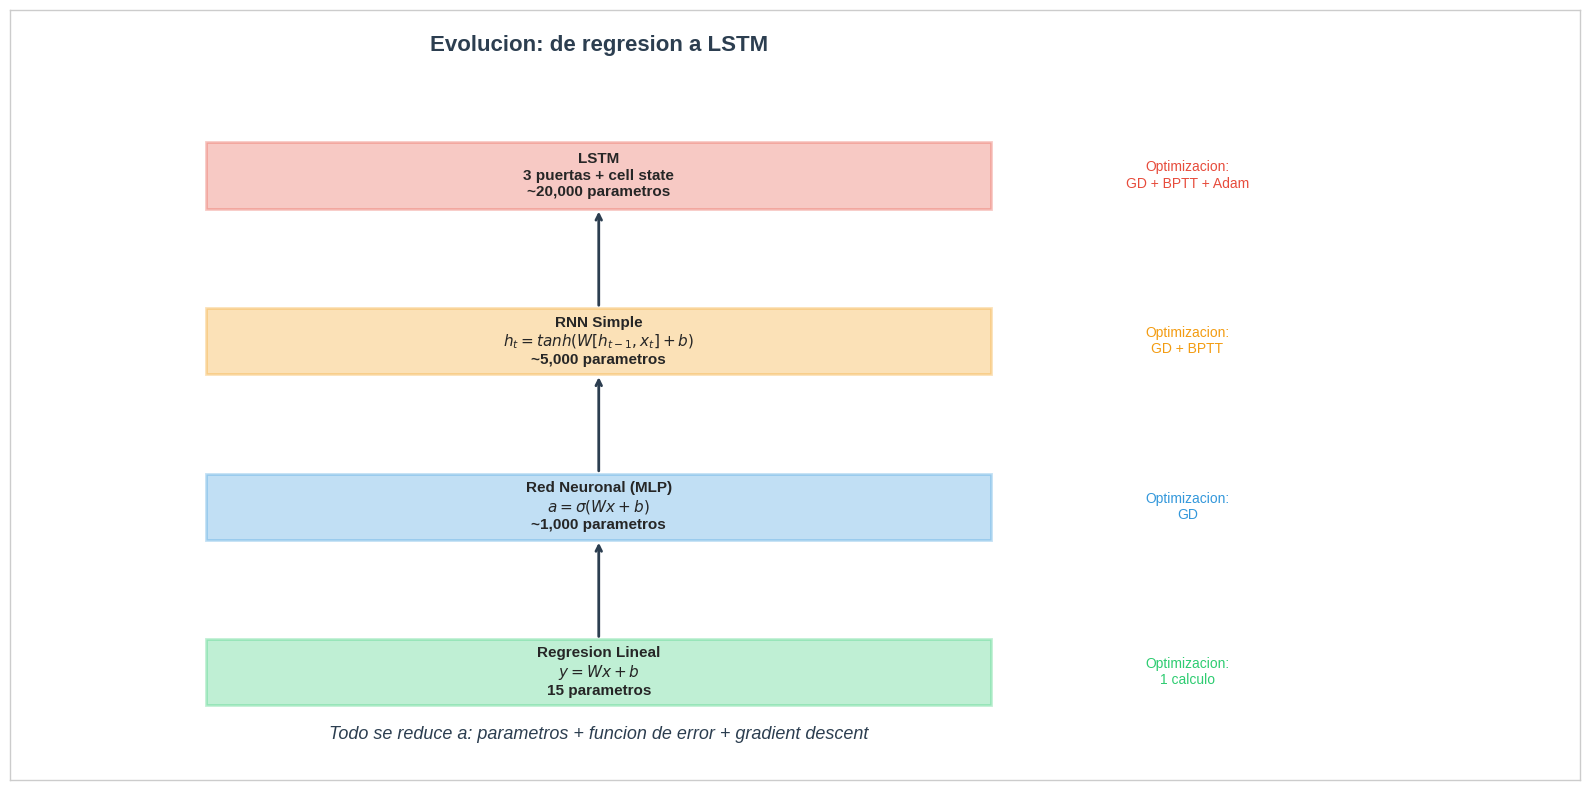

In [9]:
# === Diagrama resumen visual ===
fig, ax = plt.subplots(figsize=(16, 8))

levels = [
    (1, 'Regresion Lineal\n$y = Wx + b$\n15 parametros', C_SUCCESS, '1 calculo'),
    (3, 'Red Neuronal (MLP)\n$a = \\sigma(Wx + b)$\n~1,000 parametros', C_PRIMARY, 'GD'),
    (5, 'RNN Simple\n$h_t = tanh(W[h_{t-1}, x_t] + b)$\n~5,000 parametros', C_ORANGE, 'GD + BPTT'),
    (7, 'LSTM\n3 puertas + cell state\n~20,000 parametros', C_DANGER, 'GD + BPTT + Adam'),
]

for y, label, color, optim in levels:
    rect = plt.Rectangle((2, y - 0.4), 8, 0.8, facecolor=color, alpha=0.3, 
                          edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(6, y, label, ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(12, y, f'Optimizacion:\n{optim}', ha='center', va='center', fontsize=10, color=color)

# Flechas
for i in range(3):
    y_start = levels[i][0] + 0.4
    y_end = levels[i+1][0] - 0.4
    ax.annotate('', xy=(6, y_end), xytext=(6, y_start),
                arrowprops=dict(arrowstyle='->', color=C_DARK, lw=2))

ax.text(6, 8.5, 'Evolucion: de regresion a LSTM', ha='center', fontsize=16, fontweight='bold', color=C_DARK)
ax.text(6, 0.2, 'Todo se reduce a: parametros + funcion de error + gradient descent',
        ha='center', fontsize=13, style='italic', color=C_DARK)

ax.set_xlim(0, 16)
ax.set_ylim(-0.3, 9)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()